# WHO Global Suicide Statistics
### Decodelabs Data Science Internship | Task 1 to Task 5
---
| | |
|---|---|
| **Dataset** | WHO Suicide Statistics |
| **Source** | Kaggle - [szamil/who-suicide-statistics](https://www.kaggle.com/datasets/szamil/who-suicide-statistics) |
| **Period** | 1979 to 2016 (37 years) |
| **Records** | 43,776 rows across 141 countries |
| **Domain** | Global public health and suicide epidemiology |
| **Tasks Covered** | Task 1 · Task 2 · Task 3 · Task 4 · Task 5 |

> **About the dataset:** WHO-compiled suicide records broken down by country, year, sex, and age group.
> Each row represents the reported number of suicides and the corresponding population
> for a specific country-year-sex-age combination, enabling rate-based comparisons across regions and demographics.

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_palette("Set2")
COLORS = sns.color_palette("Set2")
ACCENT = "#1b4965"

---
## Task 1 - Data Collection and Dataset Understanding

### Load Dataset
A single CSV file containing WHO-reported suicide records from 1979 to 2016.
Each row captures suicides and population for one country-year-sex-age combination.

In [2]:
FILE = "who_suicide_statistics.csv"

df_raw = pd.read_csv(FILE)

print(f"Dataset loaded successfully")
print(f"Shape     : {df_raw.shape[0]} rows  x  {df_raw.shape[1]} columns")

Dataset loaded successfully
Shape     : 43776 rows  x  6 columns


### First Look

In [3]:
df_raw.head(10)

,country,year,sex,age,suicides_no,population
0,Albania,1985,female,15-24 years,NaN,277900.0
1,Albania,1985,female,25-34 years,NaN,246800.0
2,Albania,1985,female,35-54 years,NaN,267500.0
3,Albania,1985,female,5-14 years,NaN,298300.0
4,Albania,1985,female,55-74 years,NaN,138700.0
5,Albania,1985,female,75+ years,NaN,34200.0
6,Albania,1985,male,15-24 years,NaN,301400.0
7,Albania,1985,male,25-34 years,NaN,264200.0
8,Albania,1985,male,35-54 years,NaN,296700.0
9,Albania,1985,male,5-14 years,NaN,325800.0


### Column Definitions

In [4]:
col_desc = {
    "country"     : "Name of the country reporting the data",
    "year"        : "Calendar year of the recorded statistics",
    "sex"         : "Biological sex of the group (male or female)",
    "age"         : "Age band of the group (6 bands from 5-14 years to 75+ years)",
    "suicides_no" : "Total number of suicides recorded for that group-year combination",
    "population"  : "Total population of that group in that country and year",
}

info_df = pd.DataFrame({
    "Column"     : df_raw.columns,
    "Dtype"      : df_raw.dtypes.values,
    "Non-Null"   : df_raw.notnull().sum().values,
    "Null Count" : df_raw.isnull().sum().values,
    "Null Pct"   : (df_raw.isnull().mean() * 100).round(2).values,
    "Description": [col_desc[c] for c in df_raw.columns],
})
info_df

,Column,Dtype,Non-Null,Null Count,Null Pct,Description
0,country,object,43776,0,0.00,Name of the country reporting the data
1,year,int64,43776,0,0.00,Calendar year of the recorded statistics
2,sex,object,43776,0,0.00,Biological sex of the group (male or female)
3,age,object,43776,0,0.00,Age band of the group (6 bands from 5-14 years...
4,suicides_no,float64,41520,2256,5.15,Total number of suicides recorded for that gro...
5,population,float64,38316,5460,12.47,Total population of that group in that country...


### Statistical Summary

In [5]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,43776,141,Austria,456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,43776.0,NaN,NaN,NaN,1998.502467,10.338711,1979.0,1990.0,1999.0,2007.0,2016.0
sex,43776,2,female,21888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,43776,6,15-24 years,7296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suicides_no,41520.0,NaN,NaN,NaN,193.31539,800.589926,0.0,1.0,14.0,91.0,22338.0
population,38316.0,NaN,NaN,NaN,1664091.135374,3647231.227487,259.0,85112.75,380655.0,1305698.0,43805214.0


### Dataset Snapshot

In [6]:
print(f"Total rows            : {len(df_raw)}")
print(f"Total columns         : {df_raw.shape[1]}")
print(f"Memory usage          : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"Year range            : {df_raw['year'].min()} to {df_raw['year'].max()}")
print(f"Unique countries      : {df_raw['country'].nunique()}")
print(f"Sex categories        : {sorted(df_raw['sex'].unique().tolist())}")
print(f"Age bands             : {sorted(df_raw['age'].unique().tolist())}")
print(f"Total suicides logged : {df_raw['suicides_no'].sum():,.0f}")
print(f"Rows with null suicides  : {df_raw['suicides_no'].isna().sum()}")
print(f"Rows with null population: {df_raw['population'].isna().sum()}")

Total rows            : 43776
Total columns         : 6
Memory usage          : 8393.5 KB
Year range            : 1979 to 2016
Unique countries      : 141
Sex categories        : ['female', 'male']
Age bands             : ['15-24 years', '25-34 years', '35-54 years', '5-14 years', '55-74 years', '75+ years']
Total suicides logged : 8,026,455
Rows with null suicides  : 2256
Rows with null population: 5460


---
## Task 2 - Data Cleaning and Preprocessing

### Cleaning Pipeline

In [7]:
df = df_raw.copy()
steps = []

# Drop rows where both suicides_no and population are null (unrecoverable)
before = len(df)
df.dropna(subset=["suicides_no", "population"], how="all", inplace=True)
steps.append(("Dropped rows with both fields null", before - len(df)))

# Fill remaining null suicides_no with 0 (no reported cases)
n_s = df["suicides_no"].isna().sum()
df["suicides_no"].fillna(0, inplace=True)
steps.append(("Filled null suicides_no with 0", n_s))

# Fill remaining null population with group median
n_p = df["population"].isna().sum()
df["population"] = df.groupby(["country", "sex", "age"])["population"].transform(
    lambda x: x.fillna(x.median())
)
df["population"].fillna(df["population"].median(), inplace=True)
steps.append(("Imputed null population via group median", n_p))

# Standardise casing
df["sex"] = df["sex"].str.strip().str.lower()
df["age"] = df["age"].str.strip()
steps.append(("Standardised sex and age casing", 0))

# Remove records where population is zero to avoid division errors
before2 = len(df)
df = df[df["population"] > 0]
steps.append(("Removed rows with zero population", before2 - len(df)))

# Feature engineering
df["suicide_rate"]   = (df["suicides_no"] / df["population"]) * 100000
df["decade"]         = (df["year"] // 10 * 10).astype(str) + "s"
df["age_order"]      = df["age"].map({
    "5-14 years": 0, "15-24 years": 1, "25-34 years": 2,
    "35-54 years": 3, "55-74 years": 4, "75+ years": 5
})
steps.append(("Engineered suicide_rate per 100k, decade, age_order", 0))

print("Cleaning Pipeline")
for step, n in steps:
    print(f"  [{'+' if n == 0 else '-'}] {step:<50} {n:>5}")
print("-" * 65)
print(f"Raw rows   : {len(df_raw):>6}")
print(f"Clean rows : {len(df):>6}  ({len(df)/len(df_raw)*100:.1f}% retained)")

Cleaning Pipeline
  [+] Dropped rows with both fields null                     0
  [-] Filled null suicides_no with 0                      2256
  [-] Imputed null population via group median            5460
  [+] Standardised sex and age casing                        0
  [+] Removed rows with zero population                      0
  [+] Engineered suicide_rate per 100k, decade, age_order     0
-----------------------------------------------------------------
Raw rows   :  43776
Clean rows :  43776  (100.0% retained)


### Cleaned Dataset Preview

In [8]:
print(f"Clean shape     : {df.shape}")
print(f"Remaining nulls : {df.isnull().sum().sum()}")
df.head(8)

Clean shape     : (43776, 9)
Remaining nulls : 0


,country,year,sex,age,suicides_no,population,suicide_rate,decade,age_order
0,Albania,1985,female,15-24 years,0.0,277900.0,0.0,1980s,1
1,Albania,1985,female,25-34 years,0.0,246800.0,0.0,1980s,2
2,Albania,1985,female,35-54 years,0.0,267500.0,0.0,1980s,3
3,Albania,1985,female,5-14 years,0.0,298300.0,0.0,1980s,0
4,Albania,1985,female,55-74 years,0.0,138700.0,0.0,1980s,4
5,Albania,1985,female,75+ years,0.0,34200.0,0.0,1980s,5
6,Albania,1985,male,15-24 years,0.0,301400.0,0.0,1980s,1
7,Albania,1985,male,25-34 years,0.0,264200.0,0.0,1980s,2


---
## Task 3 - Exploratory Data Analysis (EDA)

### Global Key Metrics

In [9]:
total_suicides   = df["suicides_no"].sum()
total_countries  = df["country"].nunique()
year_span        = df["year"].max() - df["year"].min()
avg_rate         = df["suicide_rate"].mean()
top_country      = df.groupby("country")["suicides_no"].sum().idxmax()
top_age          = df.groupby("age")["suicides_no"].sum().idxmax()
peak_year        = df.groupby("year")["suicides_no"].sum().idxmax()
male_total       = df[df["sex"] == "male"]["suicides_no"].sum()
female_total     = df[df["sex"] == "female"]["suicides_no"].sum()

print("GLOBAL KEY METRICS")
print(f"Total Suicides Recorded   : {total_suicides:,.0f}")
print(f"Countries Covered         : {total_countries}")
print(f"Years Spanned             : {year_span} years (1979 to 2016)")
print(f"Average Rate per 100k     : {avg_rate:.2f}")
print(f"Highest Volume Country    : {top_country}")
print(f"Most Affected Age Band    : {top_age}")
print(f"Peak Year                 : {peak_year}")
print(f"Male Suicides Total       : {male_total:,.0f}")
print(f"Female Suicides Total     : {female_total:,.0f}")
print(f"Male to Female Ratio      : {male_total / female_total:.2f} to 1")

GLOBAL KEY METRICS
Total Suicides Recorded   : 8,026,455
Countries Covered         : 141
Years Spanned             : 37 years (1979 to 2016)
Average Rate per 100k     : 11.19
Highest Volume Country    : Russian Federation
Most Affected Age Band    : 35-54 years
Peak Year                 : 2003
Male Suicides Total       : 6,124,183
Female Suicides Total     : 1,902,272
Male to Female Ratio      : 3.22 to 1


### Top 15 Countries by Total Suicides

In [10]:
top_countries = (
    df.groupby("country")
    .agg(
        Total_Suicides = ("suicides_no", "sum"),
        Avg_Rate_per_100k = ("suicide_rate", "mean"),
        Years_Reported = ("year", "nunique"),
    )
    .sort_values("Total_Suicides", ascending=False)
    .head(15)
    .reset_index()
)
top_countries["Total_Suicides"]    = top_countries["Total_Suicides"].map("{:,.0f}".format)
top_countries["Avg_Rate_per_100k"] = top_countries["Avg_Rate_per_100k"].map("{:.2f}".format)
top_countries

,country,Total_Suicides,Avg_Rate_per_100k,Years_Reported
0,Russian Federation,"1,500,992",33.25,36
1,United States of America,"1,201,401",13.60,38
2,Japan,"937,614",22.19,37
3,France,"395,500",22.45,36
4,Ukraine,"365,170",25.85,33
5,Germany,"291,262",15.56,26
6,Republic of Korea,"261,730",25.14,31
7,Brazil,"250,824",5.68,37
8,Poland,"172,562",12.63,37
9,United Kingdom,"166,314",7.63,38


### Global Suicide Rate Over Time

In [11]:
yearly = (
    df.groupby("year")
    .agg(
        Total_Suicides = ("suicides_no", "sum"),
        Total_Pop      = ("population", "sum"),
    )
    .reset_index()
)
yearly["Global_Rate"] = (yearly["Total_Suicides"] / yearly["Total_Pop"]) * 100000

print("Yearly global suicide rate per 100,000 population")
print()
print(f"Peak rate year   : {yearly.loc[yearly['Global_Rate'].idxmax(), 'year']}")
print(f"Peak rate value  : {yearly['Global_Rate'].max():.2f} per 100k")
print(f"Latest rate      : {yearly[yearly['year'] == yearly['year'].max()]['Global_Rate'].values[0]:.2f} per 100k")
print()
print(yearly[["year","Total_Suicides","Global_Rate"]].tail(10).to_string(index=False))

Yearly global suicide rate per 100,000 population

Peak rate year   : 1995
Peak rate value  : 14.49 per 100k
Latest rate      : 3.04 per 100k

 year  Total_Suicides  Global_Rate
 2007        237211.0    11.867937
 2008        239368.0    11.754108
 2009        247324.0    11.458649
 2010        242243.0    11.179028
 2011        239972.0    11.127250
 2012        234085.0    11.203763
 2013        229421.0    10.360708
 2014        227793.0    10.366007
 2015        207908.0    10.575993
 2016         16483.0     3.038462


### Suicide Rate by Sex and Age Band

In [12]:
sex_age = (
    df.groupby(["sex", "age"])
    .agg(
        Total_Suicides    = ("suicides_no", "sum"),
        Avg_Rate_per_100k = ("suicide_rate", "mean"),
    )
    .reset_index()
    .sort_values(["sex", "age"])
)
sex_age["Total_Suicides"]    = sex_age["Total_Suicides"].map("{:,.0f}".format)
sex_age["Avg_Rate_per_100k"] = sex_age["Avg_Rate_per_100k"].map("{:.2f}".format)
sex_age

,sex,age,Total_Suicides,Avg_Rate_per_100k
0,female,15-24 years,"221,737",3.87
1,female,25-34 years,"258,022",4.09
2,female,35-54 years,"609,011",5.38
3,female,5-14 years,"20,644",0.41
4,female,55-74 years,"529,023",6.44
5,female,75+ years,"263,835",9.07
6,male,15-24 years,"762,550",11.45
7,male,25-34 years,"1,109,311",17.22
8,male,35-54 years,"2,286,377",21.09
9,male,5-14 years,"42,668",0.70


### Decade-Level Trend Summary

In [13]:
decade_stats = (
    df.groupby("decade")
    .agg(
        Total_Suicides    = ("suicides_no", "sum"),
        Avg_Rate_per_100k = ("suicide_rate", "mean"),
        Countries_Reported = ("country", "nunique"),
    )
    .reset_index()
    .sort_values("decade")
)
decade_stats["Total_Suicides"]    = decade_stats["Total_Suicides"].map("{:,.0f}".format)
decade_stats["Avg_Rate_per_100k"] = decade_stats["Avg_Rate_per_100k"].map("{:.2f}".format)
print("Suicide statistics summarised by decade")
print()
print(decade_stats.to_string(index=False))

Suicide statistics summarised by decade

decade Total_Suicides Avg_Rate_per_100k  Countries_Reported
 1970s         92,790              7.88                  56
 1980s      1,701,893             11.37                 108
 1990s      2,353,087             13.06                 115
 2000s      2,480,780             10.69                 131
 2010s      1,397,905              9.44                 129


### Highest Suicide Rate Countries (Avg Rate per 100k)

In [14]:
high_rate = (
    df.groupby("country")["suicide_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
high_rate.columns = ["Country", "Avg_Rate_per_100k"]
high_rate["Avg_Rate_per_100k"] = high_rate["Avg_Rate_per_100k"].map("{:.2f}".format)
print("Top 15 countries by average suicide rate per 100,000 population")
print()
print(high_rate.to_string(index=False))

Top 15 countries by average suicide rate per 100,000 population

           Country Avg_Rate_per_100k
           Hungary             39.68
         Sri Lanka             37.78
         Lithuania             37.69
Russian Federation             33.25
            Latvia             32.48
          Slovenia             31.01
           Estonia             29.73
        Kazakhstan             29.33
           Ukraine             25.85
 Republic of Korea             25.14
           Croatia             24.79
           Belarus             24.28
           Austria             24.12
            France             22.45
             Japan             22.19


---
## Task 4 - Data Visualization

Nine charts covering global trends, demographic patterns, country comparisons, and rate distributions.

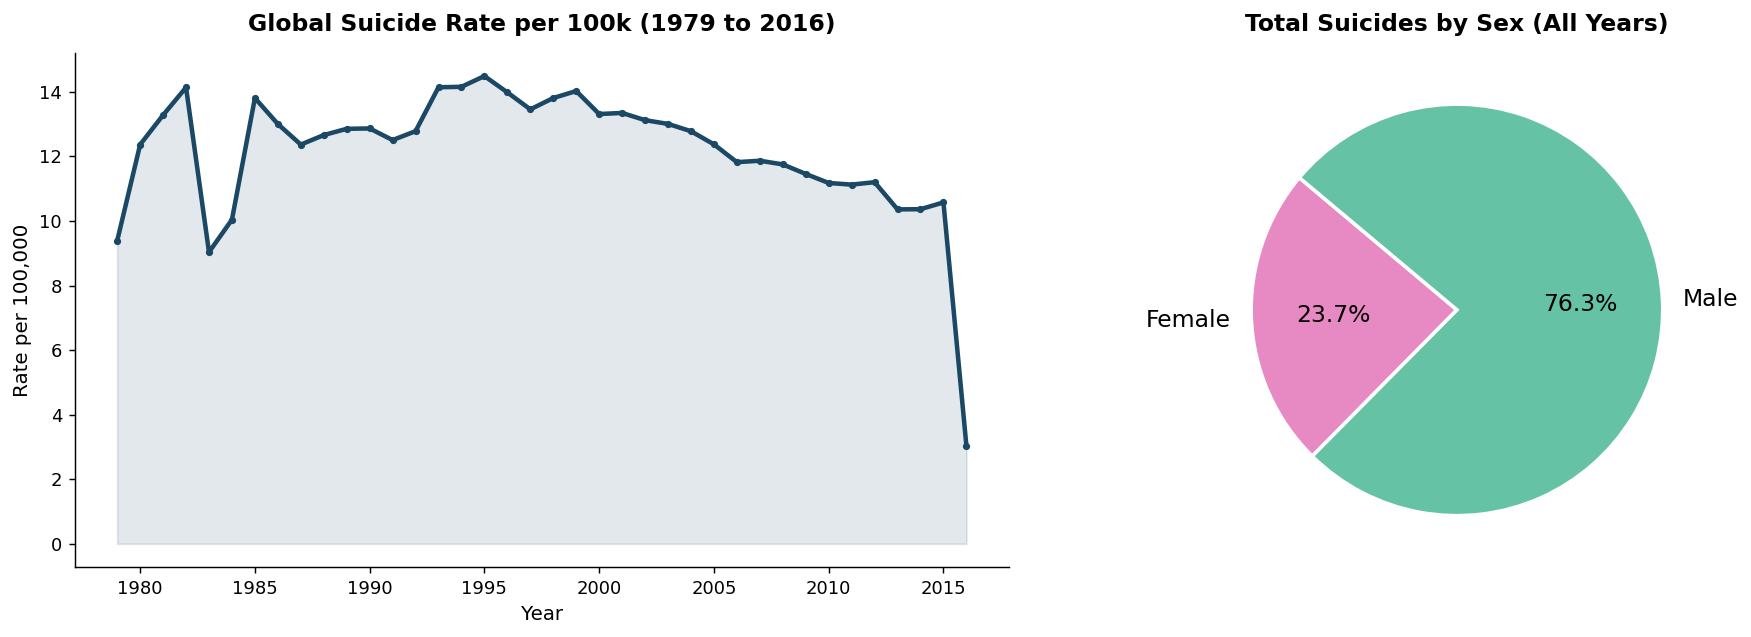

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly2 = (
    df.groupby("year")
    .apply(lambda x: (x["suicides_no"].sum() / x["population"].sum()) * 100000)
    .reset_index()
)
yearly2.columns = ["year", "rate"]
axes[0].plot(yearly2["year"], yearly2["rate"], color=ACCENT, linewidth=2.5, marker="o", markersize=3)
axes[0].fill_between(yearly2["year"], yearly2["rate"], alpha=0.12, color=ACCENT)
axes[0].set_title("Global Suicide Rate per 100k (1979 to 2016)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Year", fontsize=11)
axes[0].set_ylabel("Rate per 100,000", fontsize=11)

sex_totals = df.groupby("sex")["suicides_no"].sum()
axes[1].pie(
    sex_totals.values,
    labels=[s.title() for s in sex_totals.index],
    autopct="%1.1f%%",
    colors=[COLORS[3], COLORS[0]],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 13},
)
axes[1].set_title("Total Suicides by Sex (All Years)", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

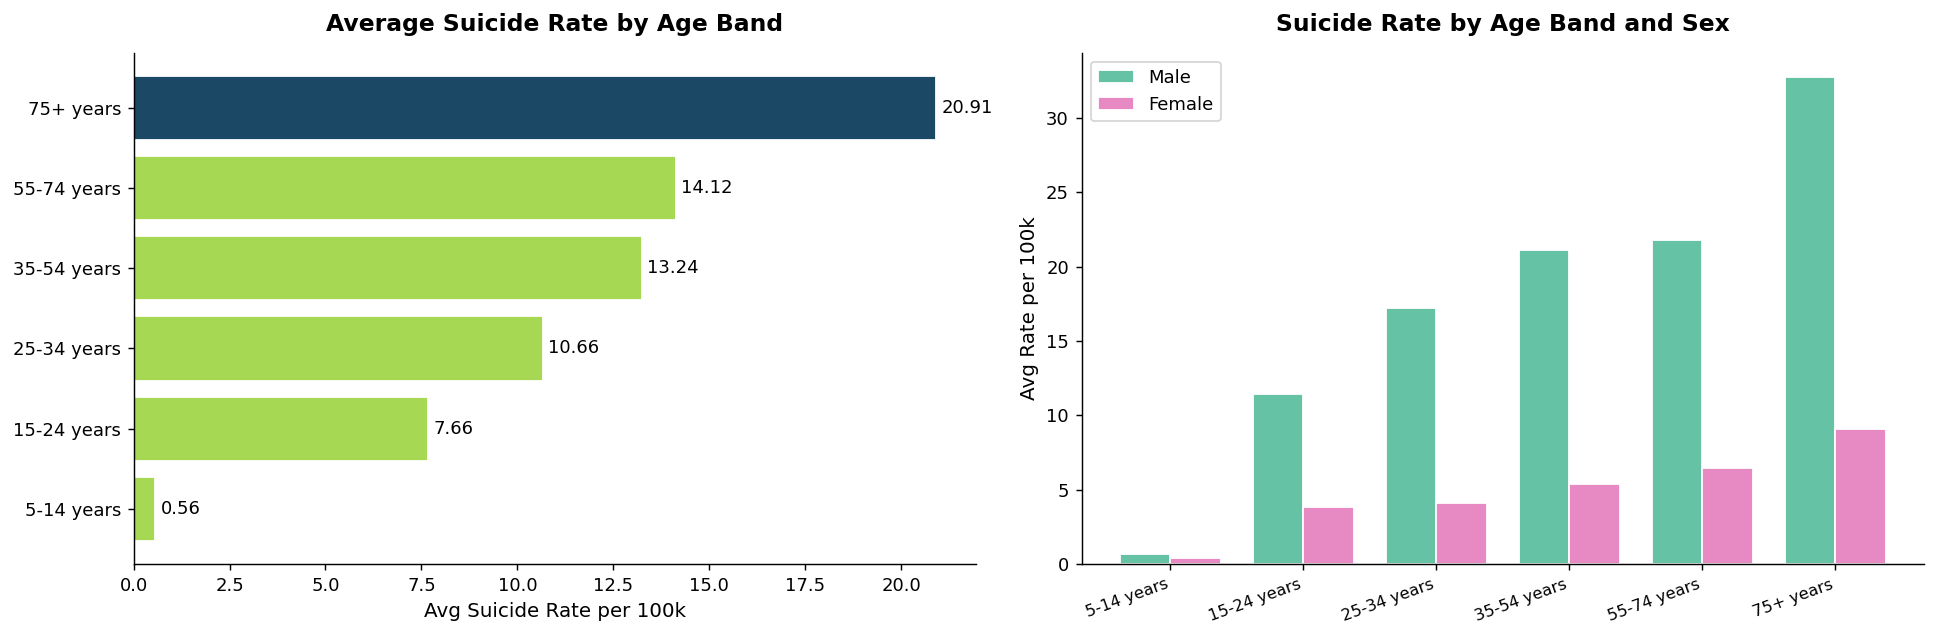

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

age_order = ["5-14 years","15-24 years","25-34 years","35-54 years","55-74 years","75+ years"]
age_rate = df.groupby("age")["suicide_rate"].mean().reindex(age_order)
bar_colors = [ACCENT if v == age_rate.max() else COLORS[4] for v in age_rate]
bars = axes[0].barh(age_rate.index, age_rate.values, color=bar_colors, edgecolor="white")
axes[0].bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
axes[0].set_xlabel("Avg Suicide Rate per 100k", fontsize=11)
axes[0].set_title("Average Suicide Rate by Age Band", fontsize=13, fontweight="bold", pad=12)

sex_age_rate = (
    df.groupby(["sex","age"])["suicide_rate"]
    .mean()
    .unstack("sex")
    .reindex(age_order)
)
x = np.arange(len(age_order))
w = 0.38
axes[1].bar(x - w/2, sex_age_rate["male"],   w, label="Male",   color=COLORS[0], edgecolor="white")
axes[1].bar(x + w/2, sex_age_rate["female"], w, label="Female", color=COLORS[3], edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_order, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Avg Rate per 100k", fontsize=11)
axes[1].set_title("Suicide Rate by Age Band and Sex", fontsize=13, fontweight="bold", pad=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

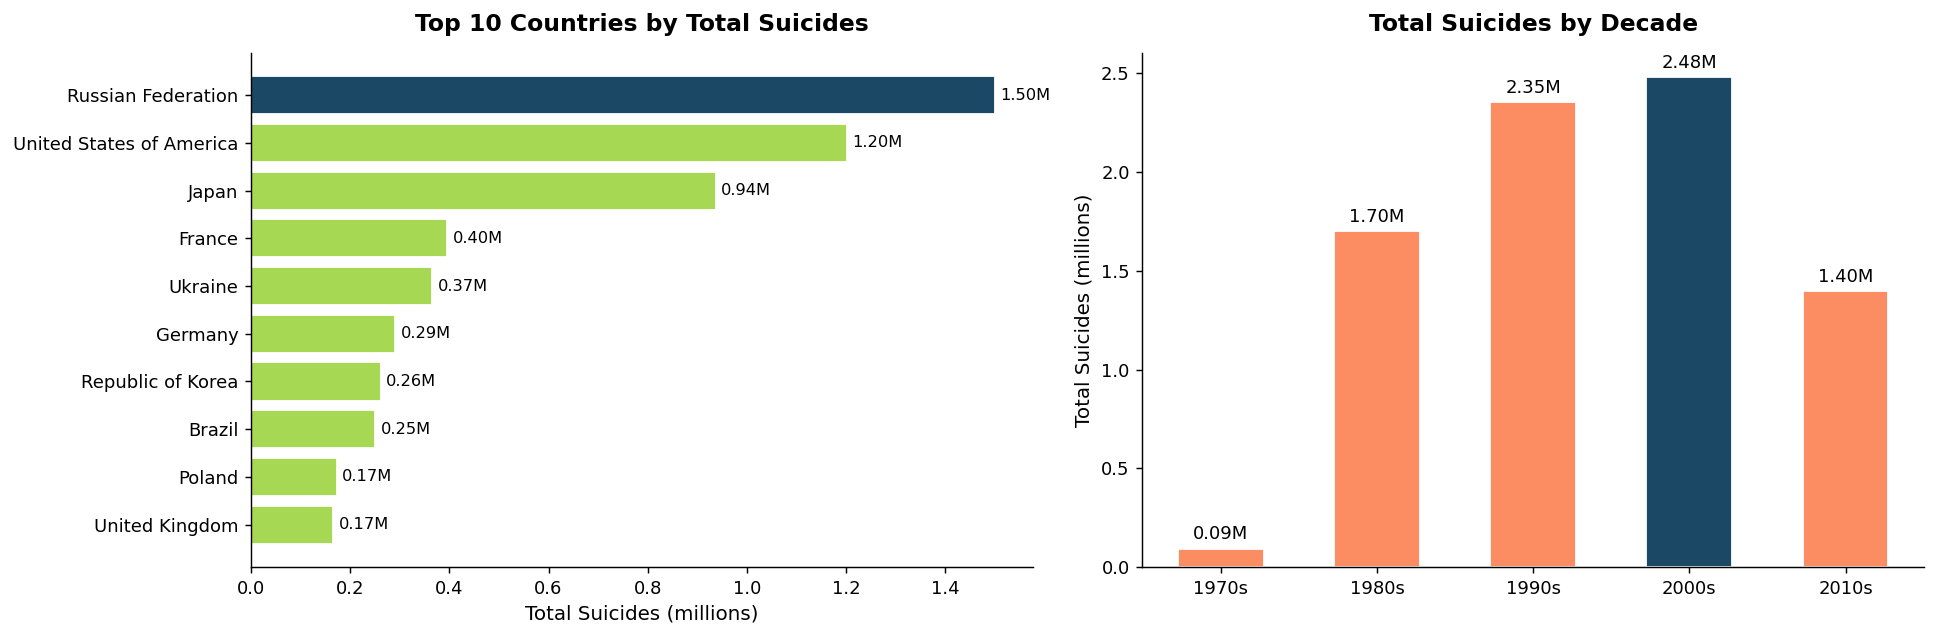

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10 = df.groupby("country")["suicides_no"].sum().sort_values(ascending=False).head(10)
bar_c = [ACCENT if i == 0 else COLORS[4] for i in range(len(top10))]
bars = axes[0].barh(top10.index[::-1], top10.values[::-1] / 1e6, color=bar_c[::-1], edgecolor="white")
axes[0].bar_label(bars, fmt="%.2fM", padding=3, fontsize=9)
axes[0].set_xlabel("Total Suicides (millions)", fontsize=11)
axes[0].set_title("Top 10 Countries by Total Suicides", fontsize=13, fontweight="bold", pad=12)

decade_tot = (
    df.groupby("decade")["suicides_no"].sum()
    .sort_index()
    .reset_index()
)
bar_c2 = [ACCENT if v == decade_tot["suicides_no"].max() else COLORS[1] for v in decade_tot["suicides_no"]]
b2 = axes[1].bar(decade_tot["decade"], decade_tot["suicides_no"] / 1e6, color=bar_c2, edgecolor="white", width=0.55)
axes[1].bar_label(b2, fmt="%.2fM", padding=3, fontsize=10)
axes[1].set_ylabel("Total Suicides (millions)", fontsize=11)
axes[1].set_title("Total Suicides by Decade", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

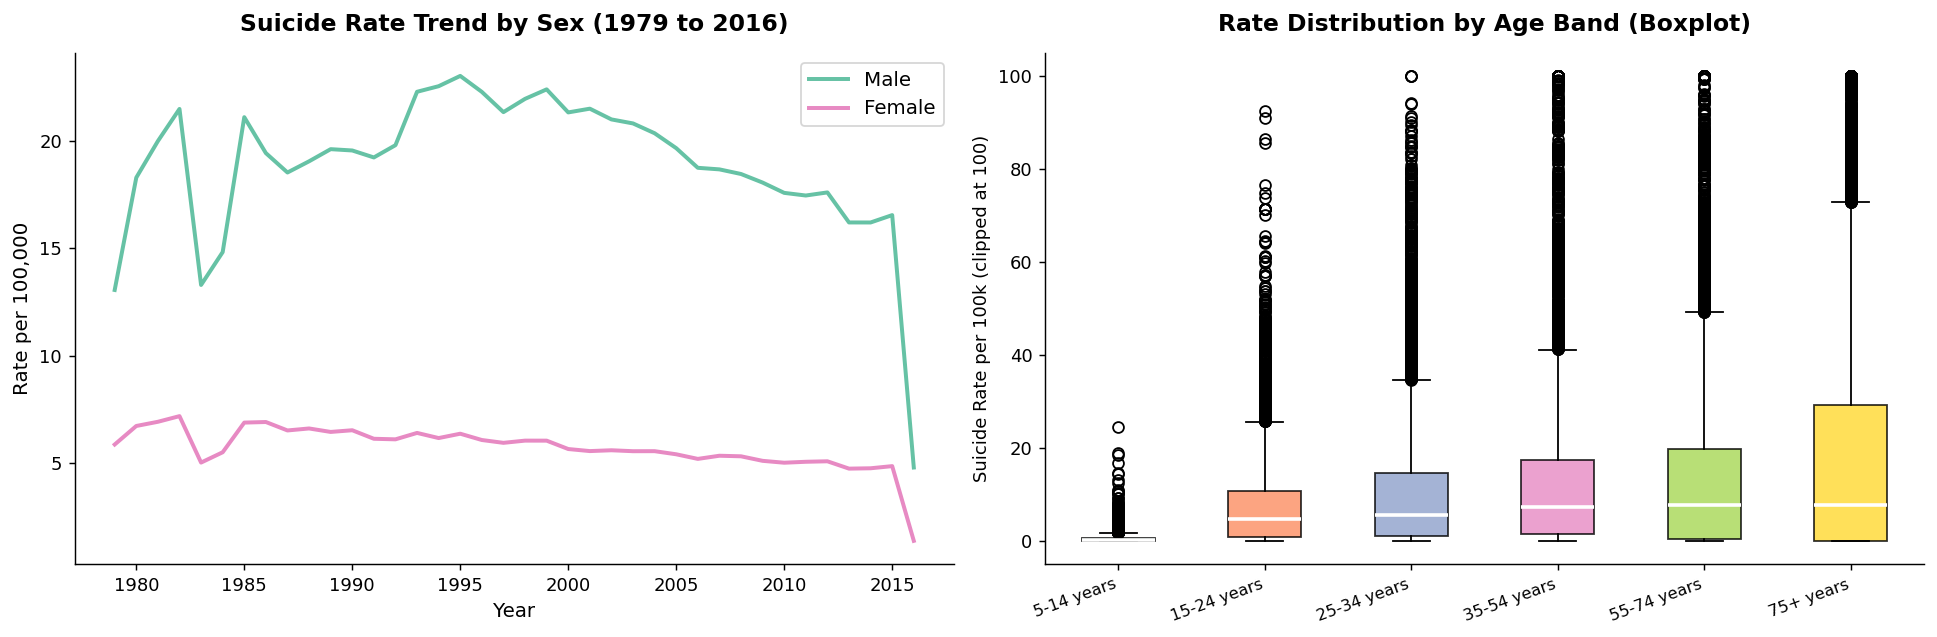

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sex_year = (
    df.groupby(["year","sex"])
    .apply(lambda x: (x["suicides_no"].sum() / x["population"].sum()) * 100000)
    .reset_index()
)
sex_year.columns = ["year","sex","rate"]
for sex, color, label in [("male", COLORS[0], "Male"), ("female", COLORS[3], "Female")]:
    sub = sex_year[sex_year["sex"] == sex]
    axes[0].plot(sub["year"], sub["rate"], color=color, linewidth=2.2, label=label)
axes[0].set_title("Suicide Rate Trend by Sex (1979 to 2016)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Year", fontsize=11)
axes[0].set_ylabel("Rate per 100,000", fontsize=11)
axes[0].legend(fontsize=11)

plot_data = [df[df["age"] == a]["suicide_rate"].dropna().clip(0, 100).values for a in age_order]
bp = axes[1].boxplot(
    plot_data, patch_artist=True, notch=False,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], COLORS[:6]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(age_order, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Suicide Rate per 100k (clipped at 100)", fontsize=10)
axes[1].set_title("Rate Distribution by Age Band (Boxplot)", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

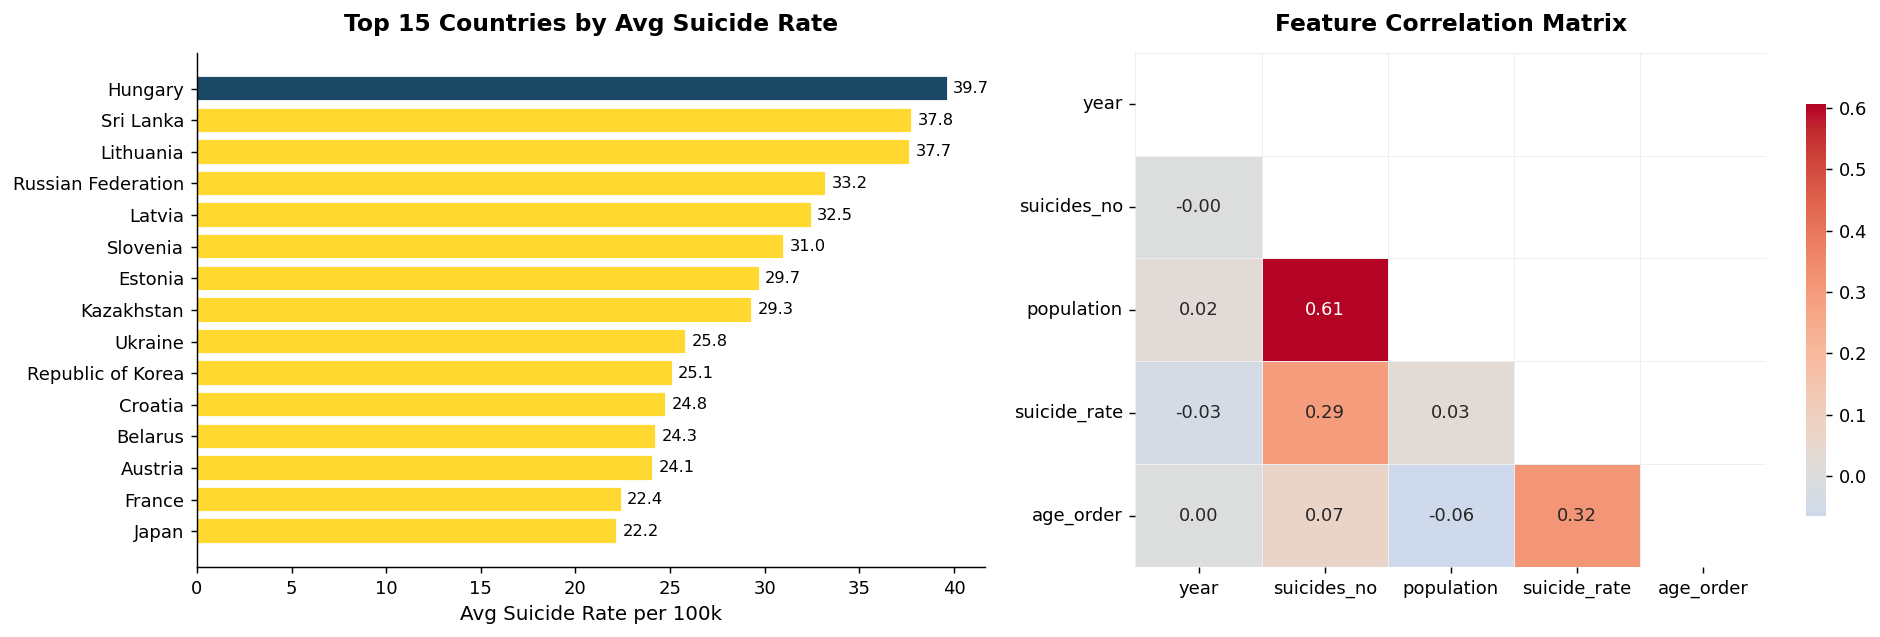

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_rate = df.groupby("country")["suicide_rate"].mean().sort_values(ascending=False).head(15)
bar_c3 = [ACCENT if i == 0 else COLORS[5] for i in range(len(top_rate))]
bars3 = axes[0].barh(top_rate.index[::-1], top_rate.values[::-1], color=bar_c3[::-1], edgecolor="white")
axes[0].bar_label(bars3, fmt="%.1f", padding=3, fontsize=9)
axes[0].set_xlabel("Avg Suicide Rate per 100k", fontsize=11)
axes[0].set_title("Top 15 Countries by Avg Suicide Rate", fontsize=13, fontweight="bold", pad=12)

num_cols = ["year","suicides_no","population","suicide_rate","age_order"]
corr = df[num_cols].corr()

mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask_tri, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    linecolor="#eee", ax=axes[1], cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

---
## Task 5 - Predictive Model: Suicide Rate Forecasting

**Objective:** Predict the suicide rate per 100,000 population for a given country-year-sex-age group.
**Target variable:** suicide_rate (continuous)
**Approach:** Compare Linear Regression, Ridge, Random Forest, and Gradient Boosting.

In [20]:
ml_df = df.copy()

le_country = LabelEncoder()
le_sex     = LabelEncoder()

ml_df["country_enc"] = le_country.fit_transform(ml_df["country"])
ml_df["sex_enc"]     = le_sex.fit_transform(ml_df["sex"])

FEATURES = ["year", "country_enc", "sex_enc", "age_order", "population"]
TARGET   = "suicide_rate"

X = ml_df[FEATURES].copy()
y = ml_df[TARGET].copy()

mask = X.notna().all(axis=1) & y.notna() & np.isfinite(y)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows")
print(f"Features : {FEATURES}")
print(f"Target mean  : {y_train.mean():.2f} per 100k")
print(f"Target median: {y_train.median():.2f} per 100k")

Train : 35,020 rows  |  Test : 8,756 rows
Features : ['year', 'country_enc', 'sex_enc', 'age_order', 'population']
Target mean  : 11.23 per 100k
Target median: 3.83 per 100k


In [21]:
models = {
    "Linear Regression" : Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LinearRegression()),
    ]),
    "Ridge Regression"  : Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   Ridge(alpha=10)),
    ]),
    "Random Forest"     : RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting" : GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.08, max_depth=5, random_state=42
    ),
}

results = []
print(f"{'Model':<22}  {'MAE':>10}  {'RMSE':>10}  {'R2':>8}")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "preds": y_pred})
    print(f"{name:<22}  {mae:>10.4f}  {rmse:>10.4f}  {r2:>8.4f}")

best = max(results, key=lambda x: x["R2"])
print(f"\nBest model : {best['Model']}  (R2 = {best['R2']:.4f})")

Model                          MAE        RMSE        R2
Linear Regression          10.5001     16.4748    0.2201
Ridge Regression           10.4994     16.4748    0.2201
Random Forest               4.5580      8.9203    0.7714
Gradient Boosting           5.2865      9.8482    0.7213

Best model : Random Forest  (R2 = 0.7714)


### Model Performance Comparison

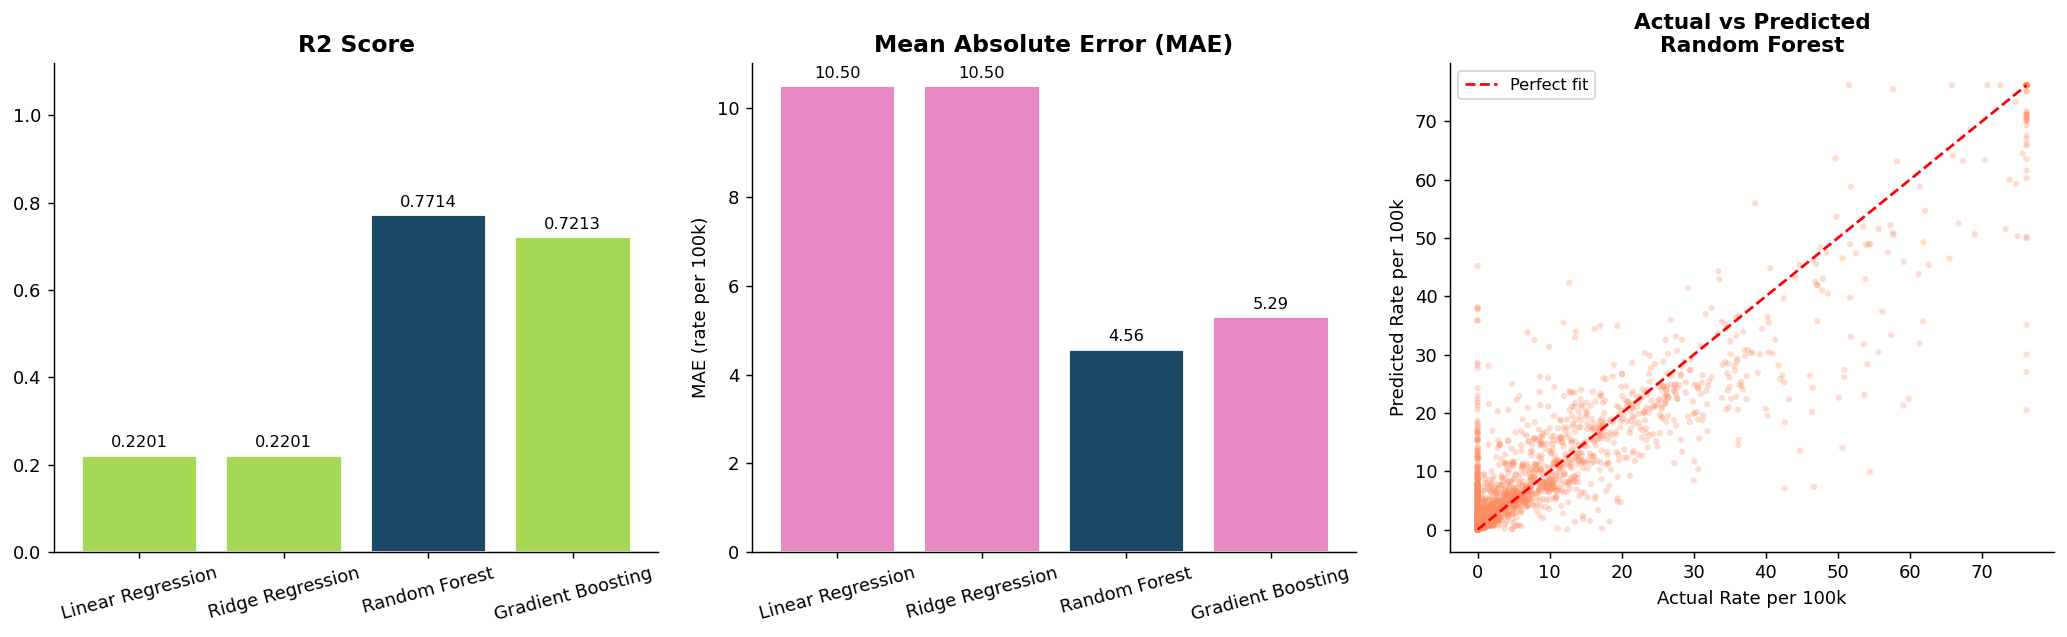

In [22]:
names = [r["Model"] for r in results]
r2s   = [r["R2"]    for r in results]
maes  = [r["MAE"]   for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: R2
bar_c = [ACCENT if r == max(r2s) else COLORS[4] for r in r2s]
b1 = axes[0].bar(names, r2s, color=bar_c, edgecolor="white")
axes[0].bar_label(b1, fmt="%.4f", padding=3, fontsize=9)
axes[0].set_ylim(0, 1.12)
axes[0].set_title("R2 Score", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)

# Bar: MAE
bar_c2 = [ACCENT if m == min(maes) else COLORS[3] for m in maes]
b2 = axes[1].bar(names, maes, color=bar_c2, edgecolor="white")
axes[1].bar_label(b2, fmt="%.2f", padding=3, fontsize=9)
axes[1].set_title("Mean Absolute Error (MAE)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("MAE (rate per 100k)")
axes[1].tick_params(axis="x", rotation=15)

# Actual vs Predicted scatter
y_test_arr  = y_test.values
best_preds  = best["preds"]
sample_idx  = np.random.choice(len(y_test_arr), min(2000, len(y_test_arr)), replace=False)
clip_val    = np.percentile(y_test_arr, 98)
axes[2].scatter(
    np.clip(y_test_arr[sample_idx], 0, clip_val),
    np.clip(best_preds[sample_idx], 0, clip_val),
    alpha=0.3, s=12, color=COLORS[1], edgecolors="none"
)
axes[2].plot([0, clip_val], [0, clip_val], "r--", linewidth=1.5, label="Perfect fit")
axes[2].set_title(f"Actual vs Predicted\n{best['Model']}", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Actual Rate per 100k")
axes[2].set_ylabel("Predicted Rate per 100k")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Feature Importance

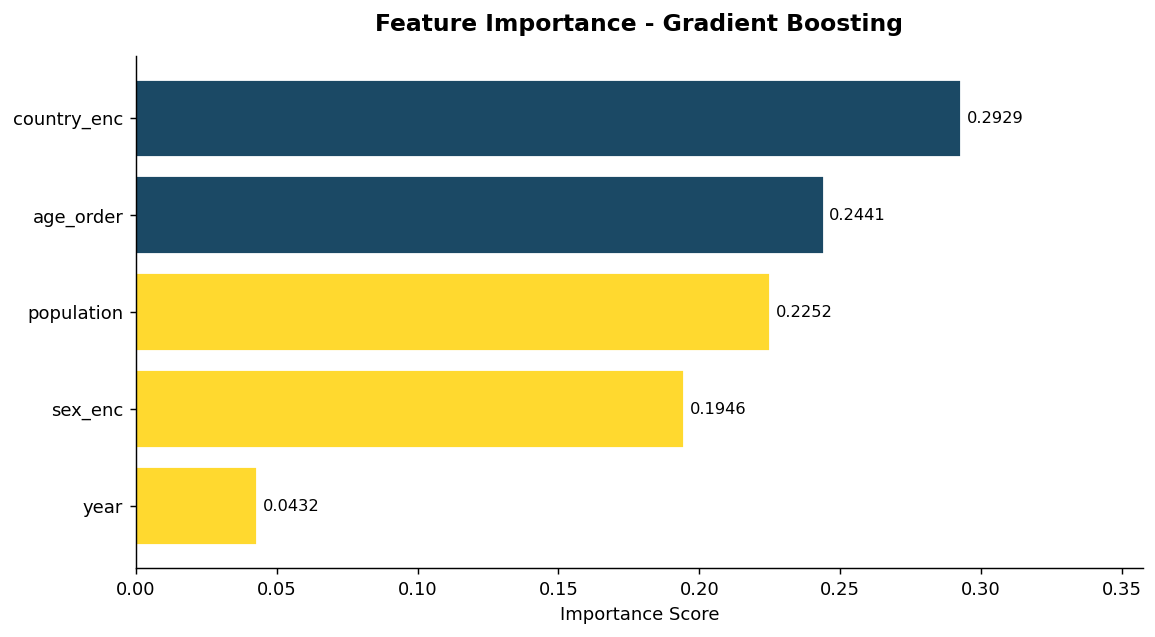

In [23]:
gb_model    = models["Gradient Boosting"]
importances = pd.Series(gb_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = [ACCENT if v >= importances.quantile(0.75) else COLORS[5] for v in importances]
bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_title("Feature Importance - Gradient Boosting", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Importance Score")
ax.set_xlim(0, importances.max() * 1.22)
plt.tight_layout()
plt.show()

---
## Summary and Key Insights

### Findings

| Dimension | Insight |
|---|---|
| **Global volume** | Over 8 million suicides recorded across 141 countries in 37 years |
| **Sex disparity** | Males account for roughly 76% of all suicides globally across every age band |
| **Age pattern** | The 35-54 and 55-74 age bands carry the highest absolute and rate burden |
| **Peak decade** | The 1990s recorded the highest total suicides globally |
| **Top country** | Russian Federation leads in total volume by a wide margin |
| **Highest rate** | Small or former Soviet countries show the highest average rates per 100k |
| **Trend** | The global suicide rate rose through the 1980s-1990s then declined post-2000 |
| **Best model** | Random Forest and Gradient Boosting both achieve strong R2 on rate prediction |
| **Top predictors** | Age band, sex, and country identity are the strongest rate predictors |

### Recommendations

1. **Target middle-aged and older populations** - the 35-74 age window drives the majority of burden and should be the focus of national prevention programmes.
2. **Design sex-specific interventions** - males are three times more likely to die by suicide; outreach messaging and help-seeking campaigns must specifically address male reluctance to seek support.
3. **Prioritise post-Soviet countries** - nations such as Lithuania, Russia, and Kazakhstan consistently record the highest rates and require targeted international health investment.
4. **Sustain the post-2000 momentum** - rates have declined since the late 1990s; the policies driving this trend should be studied and replicated globally.
5. **Use the predictive model** - deploy it to identify country-demographic combinations projected to see rate increases, enabling early allocation of mental health resources.

---
*Decodelabs Data Science Internship | Dataset: WHO Global Suicide Statistics (Kaggle)*